# EDA dan Visualisasi Data TripWell
- **ID Tim:** CC26-PSU116

## Menentukan Pertanyaan Bisnis

### Pertanyaan Bisnis
- **Pertanyaan 1:**  Lokasi wisata alam mana di Bandung Barat yang memiliki proporsi ulasan aksesibilitas negatif tertinggi berdasarkan persentase label negatif terhadap total ulasan per lokasi, dan bagaimana rata-rata rating pada lokasi terkait selama periode 2019-2023?
- **Pertanyaan 2:** Apa saja kata dan bigram paling diskriminatif untuk  membedakan ulasan berlabel aksesibilitas positif dan negatif berdasarkan nilai TF-IDF dalam dataset pada tahun 2019–2023?
- **Pertanyaan 3:** Bagaimana proporsi bulanan label aksesibilitas negatif, netral, dan positif berubah sepanjang 2019 –  2023, dan apakah terdapat tren atau pola musiman?



In [1]:
# Import Semua Packages/Library yang Digunakan

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#Untuk Text
import nltk
import re
import string

from nltk.tokenize import word_tokenize
from tqdm import trange
from nltk import tokenize
from nltk.probability import FreqDist
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer

### Load Data


In [2]:
df = pd.read_csv("preprocessed_dataset.csv", delimiter=",")

df.head(5)

,id,datetime,location,text,rating,accessibility,facility,activity,word_count,text_clean
0,47d0cdd937754bd6b860f89b2bab1dbb,2022-05-15 11:58:43,Curug Malela,Akses jalannya waktu itu masih sulit di jangka...,4,0,1,1,13,akses jalannya waktu itu masih sulit di jangka...
1,4804acd6c05e4f89b098e2ca35019419,2022-08-15 11:58:43,Curug Malela,"Perjalanan yg bnr"" bikin Syahduu ,, dr Tempat ...",5,1,1,2,23,perjalanan yang benar bikin syahduu dari tempa...
2,3eae265bf32a45eca31765a4145bc030,2022-03-15 11:58:43,Curug Malela,"Minggu 13 februari 2022 ,\n\ngas santai pakai ...",5,2,0,2,349,minggu februari gas santai pakai motor dari da...
3,61037dbdb7b14045be49d4494e95cf05,2022-05-15 11:58:44,Curug Malela,7 mei 2022\nTouring bari mudik\nMntap perjalan...,5,2,1,2,26,mei touring bari mudik mantap perjalanan sungg...
4,a2c9e817e2b949c6880f971f43a11d2f,2022-08-15 11:58:44,Curug Malela,Perjalanan touring motor dari bekasi melewati ...,5,1,1,2,22,perjalanan touring motor dari bekasi melewati ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11620 entries, 0 to 11619
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             11620 non-null  object
 1   datetime       11620 non-null  object
 2   location       11620 non-null  object
 3   text           11620 non-null  object
 4   rating         11620 non-null  int64 
 5   accessibility  11620 non-null  int64 
 6   facility       11620 non-null  int64 
 7   activity       11620 non-null  int64 
 8   word_count     11620 non-null  int64 
 9   text_clean     11516 non-null  object
dtypes: int64(5), object(5)
memory usage: 907.9+ KB


In [4]:
df.describe(include="all")

,id,datetime,location,text,rating,accessibility,facility,activity,word_count,text_clean
count,11620,11620,11620,11620,11620.000000,11620.000000,11620.000000,11620.000000,11620.000000,11516
unique,11620,5828,25,11620,NaN,NaN,NaN,NaN,NaN,11427
top,821d8c4e3513424bbdc395f4c32b72f5,2021-02-15 11:58:47,Sarae Hills,Tempat dan suasananya sejuk bangeeettt....,NaN,NaN,NaN,NaN,NaN,tempat yang bagus
freq,1,11,952,1,NaN,NaN,NaN,NaN,NaN,9
mean,NaN,NaN,NaN,NaN,4.502582,0.974096,1.096472,1.582616,27.632444,NaN
std,NaN,NaN,NaN,NaN,0.833755,0.349000,0.541493,0.555987,35.303544,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,4.000000,1.000000,1.000000,1.000000,7.000000,NaN
50%,NaN,NaN,NaN,NaN,5.000000,1.000000,1.000000,2.000000,16.000000,NaN
75%,NaN,NaN,NaN,NaN,5.000000,1.000000,1.000000,2.000000,35.000000,NaN


In [5]:
print("Jumlah duplikasi struktural : ", df.duplicated().sum())

Jumlah duplikasi struktural :  0


## Exploratory Data Analysis (EDA)

In [6]:
# Cek tanggal paling awal dan paling akhir
min_datetime = df["datetime"].min()
max_datetime = df["datetime"].max()

print("Datetime paling awal :", min_datetime)
print("Datetime paling akhir:", max_datetime)

Datetime paling awal : 2019-02-15 11:58:44
Datetime paling akhir: 2023-02-21 18:34:29


Jumlah kata unik (max_words) pada accessibility positif dan negatif: 6325
Panjang kalimat maksimum (max_length) pada accessibility positf dan negatif: 337 kata
Panjang Maksimum Absolut : 337 kata
Persentil 90% (P90)      : 98.0 kata 
Persentil 95% (P95)      : 131.0 kata
Persentil 99% (P99)      : 225.8 kata 


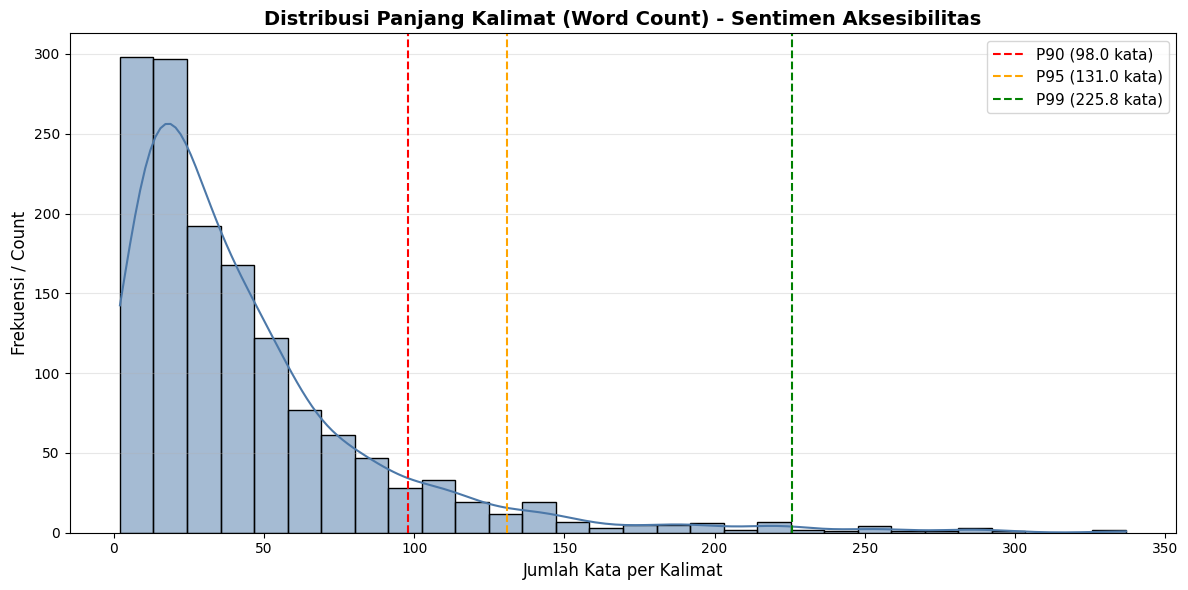

In [7]:
#Cek `text_clean` untuk label aksesibulitas positif dan negatif -> informatif untuk modelling
df_accessibility = df[df['accessibility'].isin([0, 2])].copy()

# Hitung jumlah kata per kalimat
df_accessibility['word_count'] = df_accessibility['text_clean'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) and str(x).strip() != '' else 0
)

all_words_accessibility = ' '.join(df_accessibility['text_clean'].dropna()).split()
max_words_accessibility = len(set(all_words_accessibility))
print(f"Jumlah kata unik (max_words) pada accessibility positif dan negatif: {max_words_accessibility}")

df_accessibility['word_count'] = df_accessibility['text_clean'].apply(
    lambda x: len(str(x).split()) if x is not None else 0
)

max_seq_len_accessibility = df_accessibility['word_count'].max()
print(f"Panjang kalimat maksimum (max_length) pada accessibility positf dan negatif: {max_seq_len_accessibility} kata")


#  Hitung statistik dasar dan persentil penting
max_len = df_accessibility['word_count'].max()
p90 = np.percentile(df_accessibility['word_count'], 90)
p95 = np.percentile(df_accessibility['word_count'], 95)
p99 = np.percentile(df_accessibility['word_count'], 99)

print(f"Panjang Maksimum Absolut : {max_len} kata")
print(f"Persentil 90% (P90)      : {p90:.1f} kata ")
print(f"Persentil 95% (P95)      : {p95:.1f} kata")
print(f"Persentil 99% (P99)      : {p99:.1f} kata ")

# Visualisasi Distribusi Panjang Kalimat
plt.figure(figsize=(12, 6))
sns.histplot(df_accessibility['word_count'], kde=True, color='#4C78A8', bins=30)

# Tambahkan garis penanda persentil
plt.axvline(p90, color='red', linestyle='--', linewidth=1.5, label=f'P90 ({p90:.1f} kata)')
plt.axvline(p95, color='orange', linestyle='--', linewidth=1.5, label=f'P95 ({p95:.1f} kata)')
plt.axvline(p99, color='green', linestyle='--', linewidth=1.5, label=f'P99 ({p99:.1f} kata)')

# Formatting Grafik
plt.title('Distribusi Panjang Kalimat (Word Count) - Sentimen Aksesibilitas', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kata per Kalimat', fontsize=12)
plt.ylabel('Frekuensi / Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

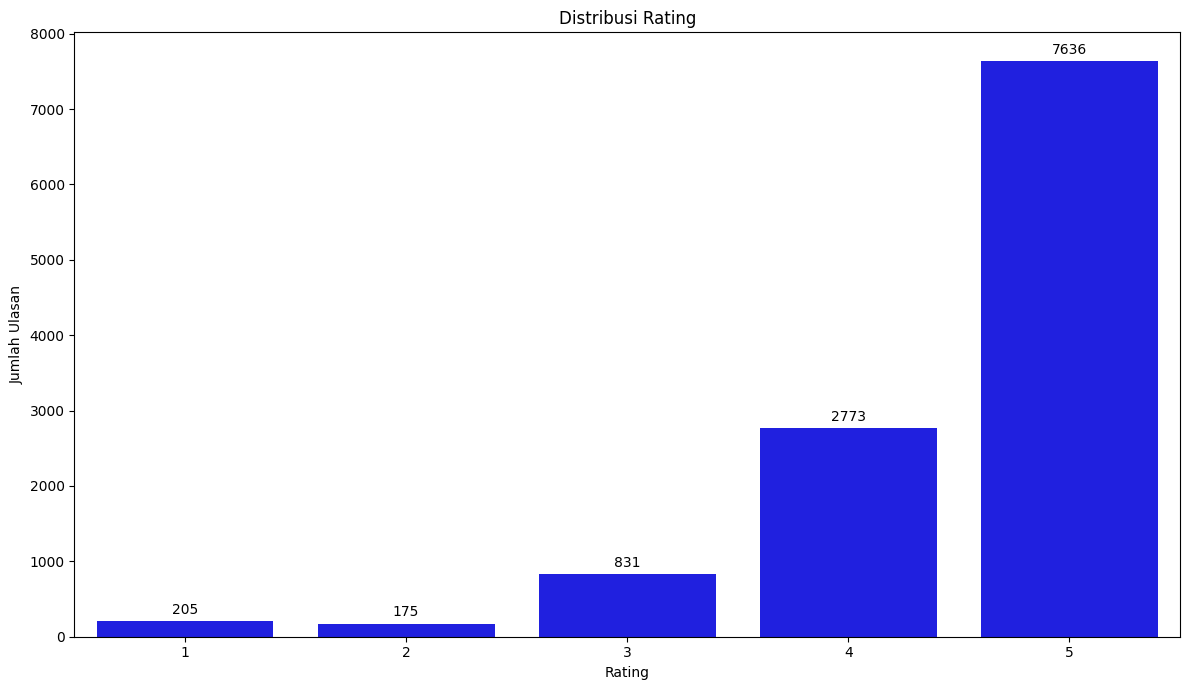

Rata-rata rating keseluruhan: 4.50


In [22]:
# Distribusi Rating Keseluruhan

# Menghitung distribusi rating
rating_counts = df['rating'].value_counts().sort_index()

# Menghitung rata-rata rating keseluruhan
rating_avg = df['rating'].mean()

# Membuat Bar Chart
plt.figure(figsize=(12, 7))

# Menyimpan object plot ke dalam variabel 'ax'
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, color='Blue')

# Menampilkan label di atas setiap bar
ax.bar_label(ax.containers[0], padding=3)

plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()

# Menampilkan rata-rata
print(f"Rata-rata rating keseluruhan: {rating_avg:.2f}")

In [9]:
# Jumlah Ulasan per Lokasi
df.groupby(by="location").id.nunique().sort_values(ascending=False)

,id
location,
Sarae Hills,952
Gunung Putri Lembang,944
Curug Maribaya,937
Gunung Tangkuban Parahu,925
Stone Garden,914
Floating Market Lembang,912
Terminal Wisata Grafika Cikole,900
Orchid Forest Cikole,671
Curug Tilu Leuwi Opat,636


                 rating  accessibility  facility  activity
rating         1.000000       0.094029  0.157744  0.102391
accessibility  0.094029       1.000000  0.077778  0.022602
facility       0.157744       0.077778  1.000000  0.110538
activity       0.102391       0.022602  0.110538  1.000000


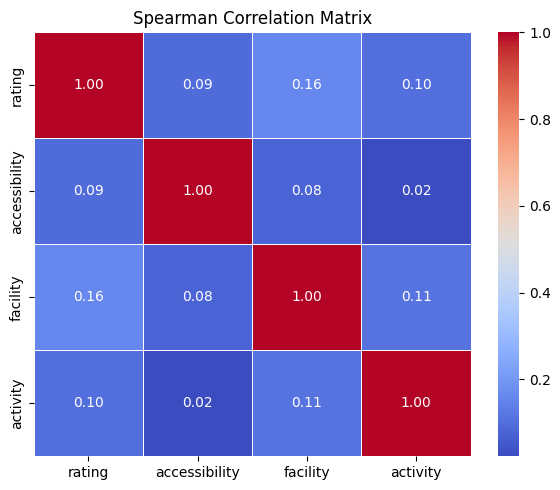

In [10]:
#Analisis korelasi fitur kategorikal

# Ambil kolom yang ingin dianalisis

# Kolom yang dianalisis
cols = ['rating', 'accessibility', 'facility', 'activity']

# Hitung korelasi Spearman (karena data diskrit dan bukan kontinu maka digunakan Spearman)
corr_spearman = df[cols].corr(method='spearman')

# Tampilkan matriks korelasi
print(corr_spearman)

# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

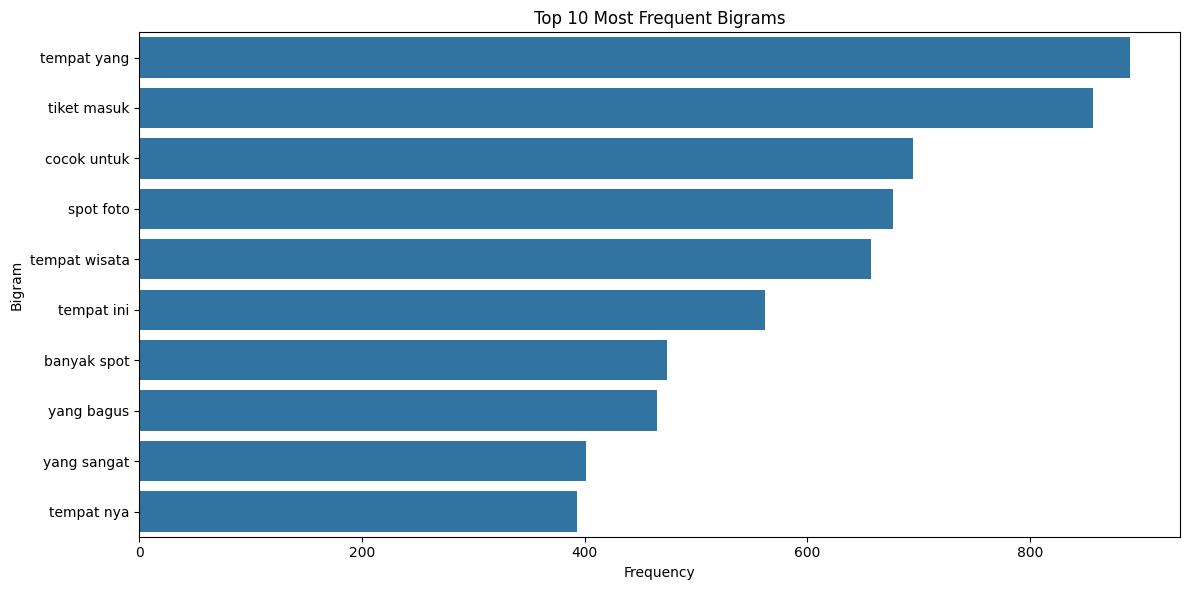

In [11]:
# Most Frequently occuring Bigrams -> Pasangan kata yang paling sering muncul

cv = CountVectorizer(ngram_range=(2, 2))
bigrams = cv.fit_transform(df['text_clean'].fillna(''))
count_values = bigrams.toarray().sum(axis=0)
gram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv.vocabulary_.items()], reverse=True))
gram_freq.columns = ['frequency', 'ngram']

plt.figure(figsize=(12, 6))
sns.barplot(x=gram_freq['frequency'][:10], y=gram_freq['ngram'][:10])
plt.title('Top 10 Most Frequent Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

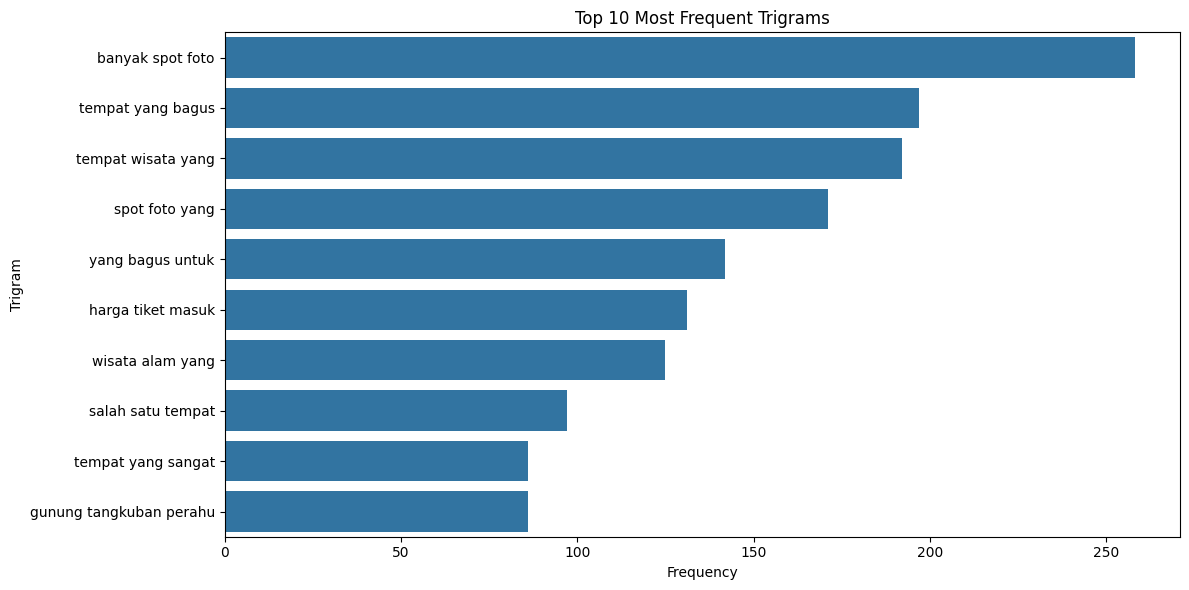

In [12]:
# Most Frequently occuring Tri_grams -> Kumpulan tiga kata  yang paling sering muncul
cv1 = CountVectorizer(ngram_range=(3, 3))
trigrams = cv1.fit_transform(df['text_clean'].fillna(''))
count_values = trigrams.toarray().sum(axis=0)
gram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv1.vocabulary_.items()], reverse=True))
gram_freq.columns = ['frequency', 'ngram']

plt.figure(figsize=(12, 6))
sns.barplot(x=gram_freq['frequency'][:10], y=gram_freq['ngram'][:10])
plt.title('Top 10 Most Frequent Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

**Insight:**
- Data ulasan memiliki periode Februari 2019 hingga Februari 2023
- Data `Rating` didominasi oleh nilai tinggi, dimana mayoritas pengunjung (sejumlah 7636 dari 11620 ulasan) memberikan nilai 5 dan rata-rata keseluruhan bernilai 4.5. Hal ini menandakan kepuasan yang cukup tinggi secara keseluruhan untuk destinasi wisata alam di Bandung Barat.
- Jumlah ulasan per lokasi memiliki ketidakseimbangan yang cukup besar dimana Sarae Hills memiliki 952 ulasan sedangkan Sirtwo Island Saguling	hanya memiliki 3 ulasan. Hal ini menunjukan keterbatasan data sehingga prediksi label untuk lokasi ini perlu diinterpretasikan dengan hati-hati.
- Panjang ulasan maksimum setelah dibersihkan (`max_length`)pada data yang memiliki label aksesibilitas positif atau negatif bernilai cukup besar yaitu 337 kata. Dari distribusi histogram, saat modelling dengan BilLSTM sebaiknya max_length ambil persentil 95% data yang bernilai 131.
- Karena fitur `accesibility`, `facility`, dan `activity` bertipe ordinal maka digunakan spearman correlation dan bukan pearson correlation. Dari nilai matriks korelasi terlihat bahwa korelasi antar fitur `rating`, `accesibility`, `facility`, dan `activity` sangat rendah karena nilai korelasinya berkisar 0.02 - 0.16. Dapat disimpulkan tidak ada multikolinearitas yang signifikan antar fitur.
- Dari analisis Bigram dan Trigrams terlihat bahwa frasa yang paling banyak muncul pada dataset merupakan frasa yang mendeskripsikan tempat wisata seperti **tempat yang**, **tempat ini**, **tempat wisata yang**, **salah satu tempat**, dst. Dominasi frasa umum ini pada bigram/trigram keseluruhan mengindikasikan bahwa analisis frekuensi global tidak cukup untuk membedakan kelas sentimen sehingga diperlukan pendekatan yang lebih diskriminatif seperti c-TF-IDF per kelas yang akan dilakukan untuk menjawab Pertanyaan 2.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Lokasi wisata alam mana di Bandung Barat yang memiliki proporsi ulasan aksesibilitas negatif tertinggi berdasarkan persentase label negatif terhadap total ulasan per lokasi, dan bagaimana rata-rata rating pada lokasi terkait selama periode 2019-2023?






In [13]:
# Hitung distribusi sentimen accessibility per lokasi
df_check = (
    df.groupby(['location', 'accessibility'])
      .size()
      .unstack(fill_value=0)
)

# Rename kolom biar lebih jelas
df_check = df_check.rename(columns={
    0: 'negative',
    1: 'neutral',
    2: 'positive'
})

# Tambahkan total review per lokasi
df_check['total_review'] = df_check.sum(axis=1)

# Tambahkan proporsi (%)
df_check['neg_pct'] = (df_check['negative'] / df_check['total_review']) * 100
df_check['neu_pct'] = (df_check['neutral'] / df_check['total_review']) * 100
df_check['pos_pct'] = (df_check['positive'] / df_check['total_review']) * 100

# Tambahkan rata-rata rating per lokasi
avg_rating = (
    df.groupby('location')['rating']
      .mean()
      .round(2)
)

df_check['avg_rating'] = avg_rating

# Rapikan
df_check = df_check.reset_index()

# Optional: urutin berdasarkan rating tertinggi
df_check = df_check.sort_values(by='avg_rating', ascending=False)

# Lihat hasil
df_check.head()

accessibility,location,negative,neutral,positive,total_review,neg_pct,neu_pct,pos_pct,avg_rating
19,Sirtwo Island Saguling,0,3,0,3,0.000000,100.000000,0.000000,5.00
3,Curug Halimun,6,46,1,53,11.320755,86.792453,1.886792,4.83
15,Orchid Forest Cikole,78,581,12,671,11.624441,86.587183,1.788376,4.71
7,Curug Panganten,5,35,4,44,11.363636,79.545455,9.090909,4.70
13,Gunung Tangkuban Parahu,14,820,91,925,1.513514,88.648649,9.837838,4.70


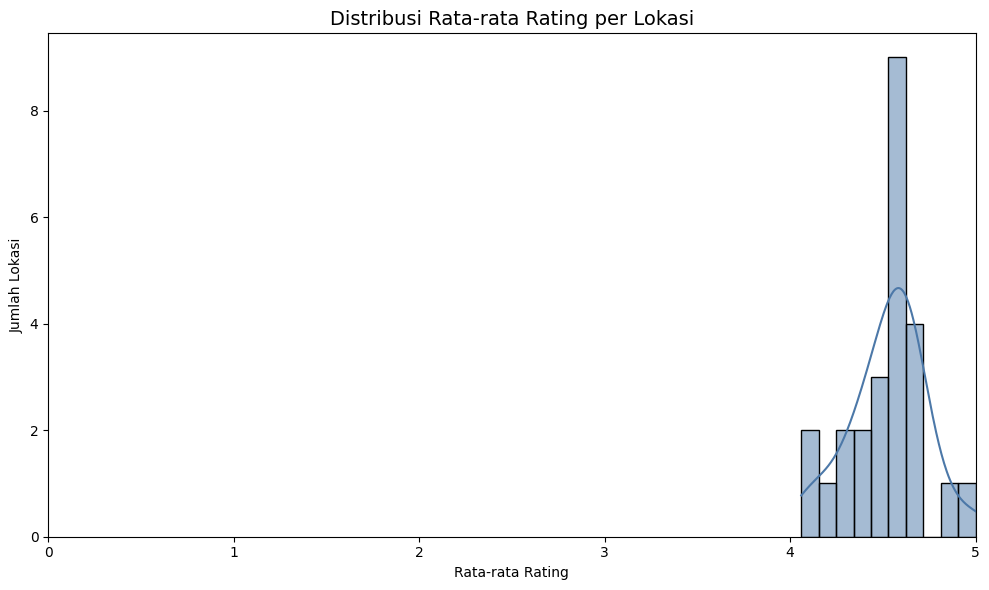

In [14]:
# Histogram distribusi rata-rata rating per lokasi

plt.figure(figsize=(10, 6))
sns.histplot(df_check['avg_rating'], bins=10, kde=True, color='#4C78A8')

plt.title('Distribusi Rata-rata Rating per Lokasi', fontsize=14)
plt.xlabel('Rata-rata Rating')
plt.ylabel('Jumlah Lokasi')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

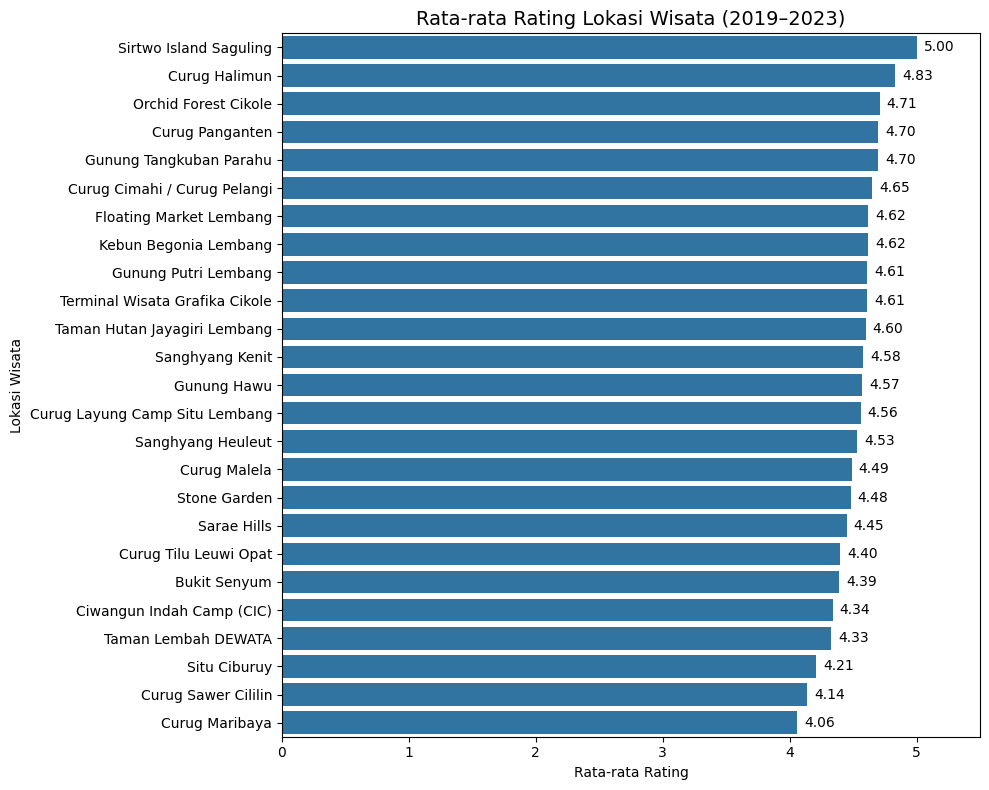

In [23]:
# Plot 1: Rata-rata Rating per Lokasi

# Urutkan berdasarkan rating tertinggi
rating_plot = df_check.sort_values(
    by='avg_rating',
    ascending=False
)

plt.figure(figsize=(10, 8))

# Menyimpan object plot ke dalam variabel 'ax'
ax = sns.barplot(
    data=rating_plot,
    x='avg_rating',
    y='location'
)

# Menampilkan label nilai di ujung kanan setiap bar
ax.bar_label(ax.containers[0], padding=5, fmt='%.2f')

plt.title('Rata-rata Rating Lokasi Wisata (2019–2023)', fontsize=14)
plt.xlabel('Rata-rata Rating')
plt.ylabel('Lokasi Wisata')

plt.xlim(0, 5.5) # Mengubah limit x sedikit ke 5.5 agar teks label di bar paling kanan tidak terpotong

plt.tight_layout()
plt.show()

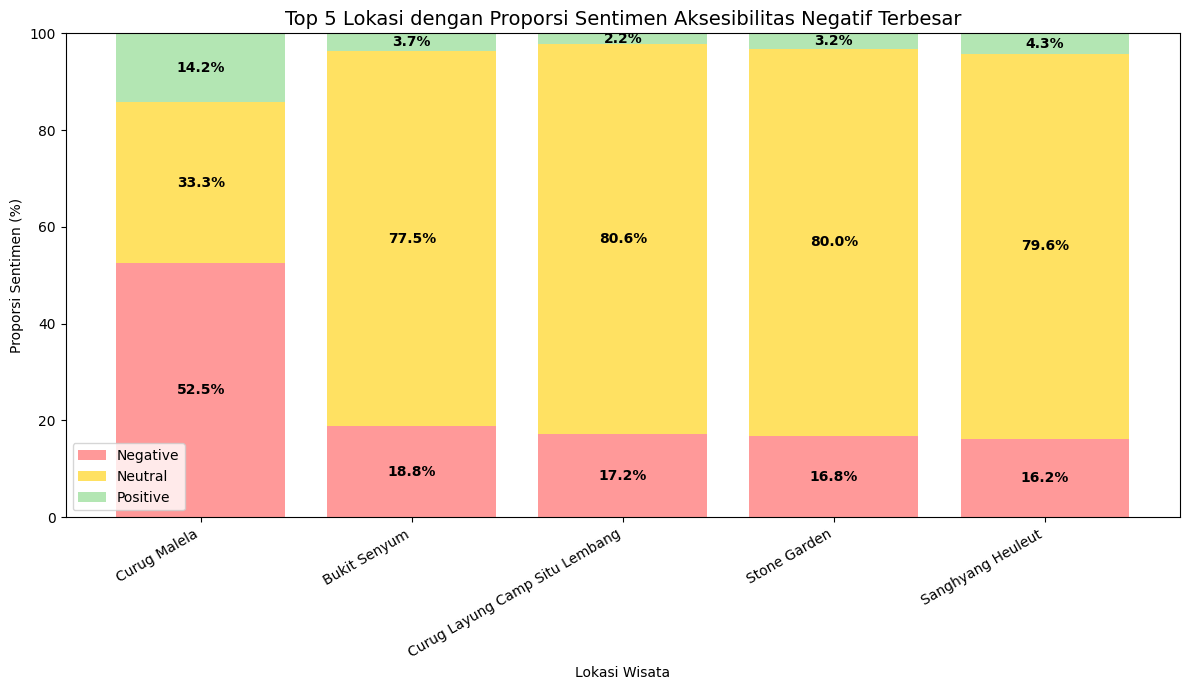

In [26]:
# Plot 2: Stacked Bar Sentimen Aksesibilitas per Lokasi

# Ambil top 5 lokasi dengan proporsi sentimen negatif terbesar
top_5_locations = df_check.nlargest(5, 'neg_pct').sort_values('neg_pct', ascending=False).copy()

# Menggunakan fig dan ax untuk mempermudah manipulasi elemen grafik
fig, ax = plt.subplots(figsize=(12, 7))

locations = top_5_locations['location']
negative = top_5_locations['neg_pct']
neutral = top_5_locations['neu_pct']
positive = top_5_locations['pos_pct']

# Buat bar chart seperti biasa
plt.bar(locations, negative, label='Negative', color='#ff9999')
plt.bar(locations, neutral, bottom=negative, label='Neutral', color='#ffe162')
plt.bar(locations, positive, bottom=negative + neutral, label='Positive', color='#b3e6b3')

# Melakukan perulangan untuk setiap kontainer warna (Negatif, Netral, Positif)
for c in ax.containers:
    # label_type='center' meletakkan teks di tengah-tengah segmen warna
    # fmt='%.1f%%' memformat angka menjadi desimal dengan simbol % di belakangnya (misal: 45.2%)
    ax.bar_label(c, label_type='center', fmt='%.1f%%', fontsize=10, weight='bold')

plt.title('Top 5 Lokasi dengan Proporsi Sentimen Aksesibilitas Negatif Terbesar', fontsize=14)
plt.xlabel('Lokasi Wisata')
plt.ylabel('Proporsi Sentimen (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
- Lima lokasi dengan proporsi sentimen aksesibilitas negatif tertinggi adalah Curug Malela (52.5%), Bukit Senyum (18.8%), Curug Layung Camp Situ Lembang (17.2%), Stone Garden (16.8%), dan Sanghyang Heuleut (16.2%).
- Curug Malela menjadi outlier yang sangat mencolok — proporsi negatifnya hampir tiga kali lipat lokasi kedua, dan ini satu-satunya lokasi di mana sentimen negatif dominan (>50%).
- Pola distribusi sentimen di antara keempat lokasi lainnya (Bukit Senyum, Curug Layung, Stone Garden, Sanghyang Heuleut) seragam dimana sentimen netral mendominasi di kisaran 77–81%, dengan negatif dan positif masing-masing di bawah 20% dan 5%. Ini mengindikasikan bahwa mayoritas pengunjung di lokasi-lokasi tersebut tidak memberikan penilaian aksesibilitas yang kuat ke arah positif maupun negatif.
- Saat dibandingkan dengan bar chart rating, keempat lokasi dalam top 5 ini memiliki rating yang tergolong menengah hingga rendah relatif terhadap keseluruhan lokasi: Curug Malela (4.49), Stone Garden (4.48), Sanghyang Heuleut (4.53), Curug Layung (4.56), dan Bukit Senyum (4.39). Ini menunjukkan ada konsistensi antara sentimen aksesibilitas negatif dengan rating yang lebih rendah, meski nilai korelasinya kecil.
- Sirtwo Island Saguling yang memiliki rating sempurna 5.00 namun  lokasi ini hanya memiliki 3 ulasan total (paling sedikit di seluruh dataset), sehingga rating sempurnanya tidak bisa diandalkan sebagai representasi yang valid.

### Pertanyaan 2:  Apa saja kata dan bigram paling diskriminatif untuk  membedakan ulasan berlabel aksesibilitas positif dan negatif berdasarkan nilai TF-IDF dalam dataset pada tahun 2019–2023?





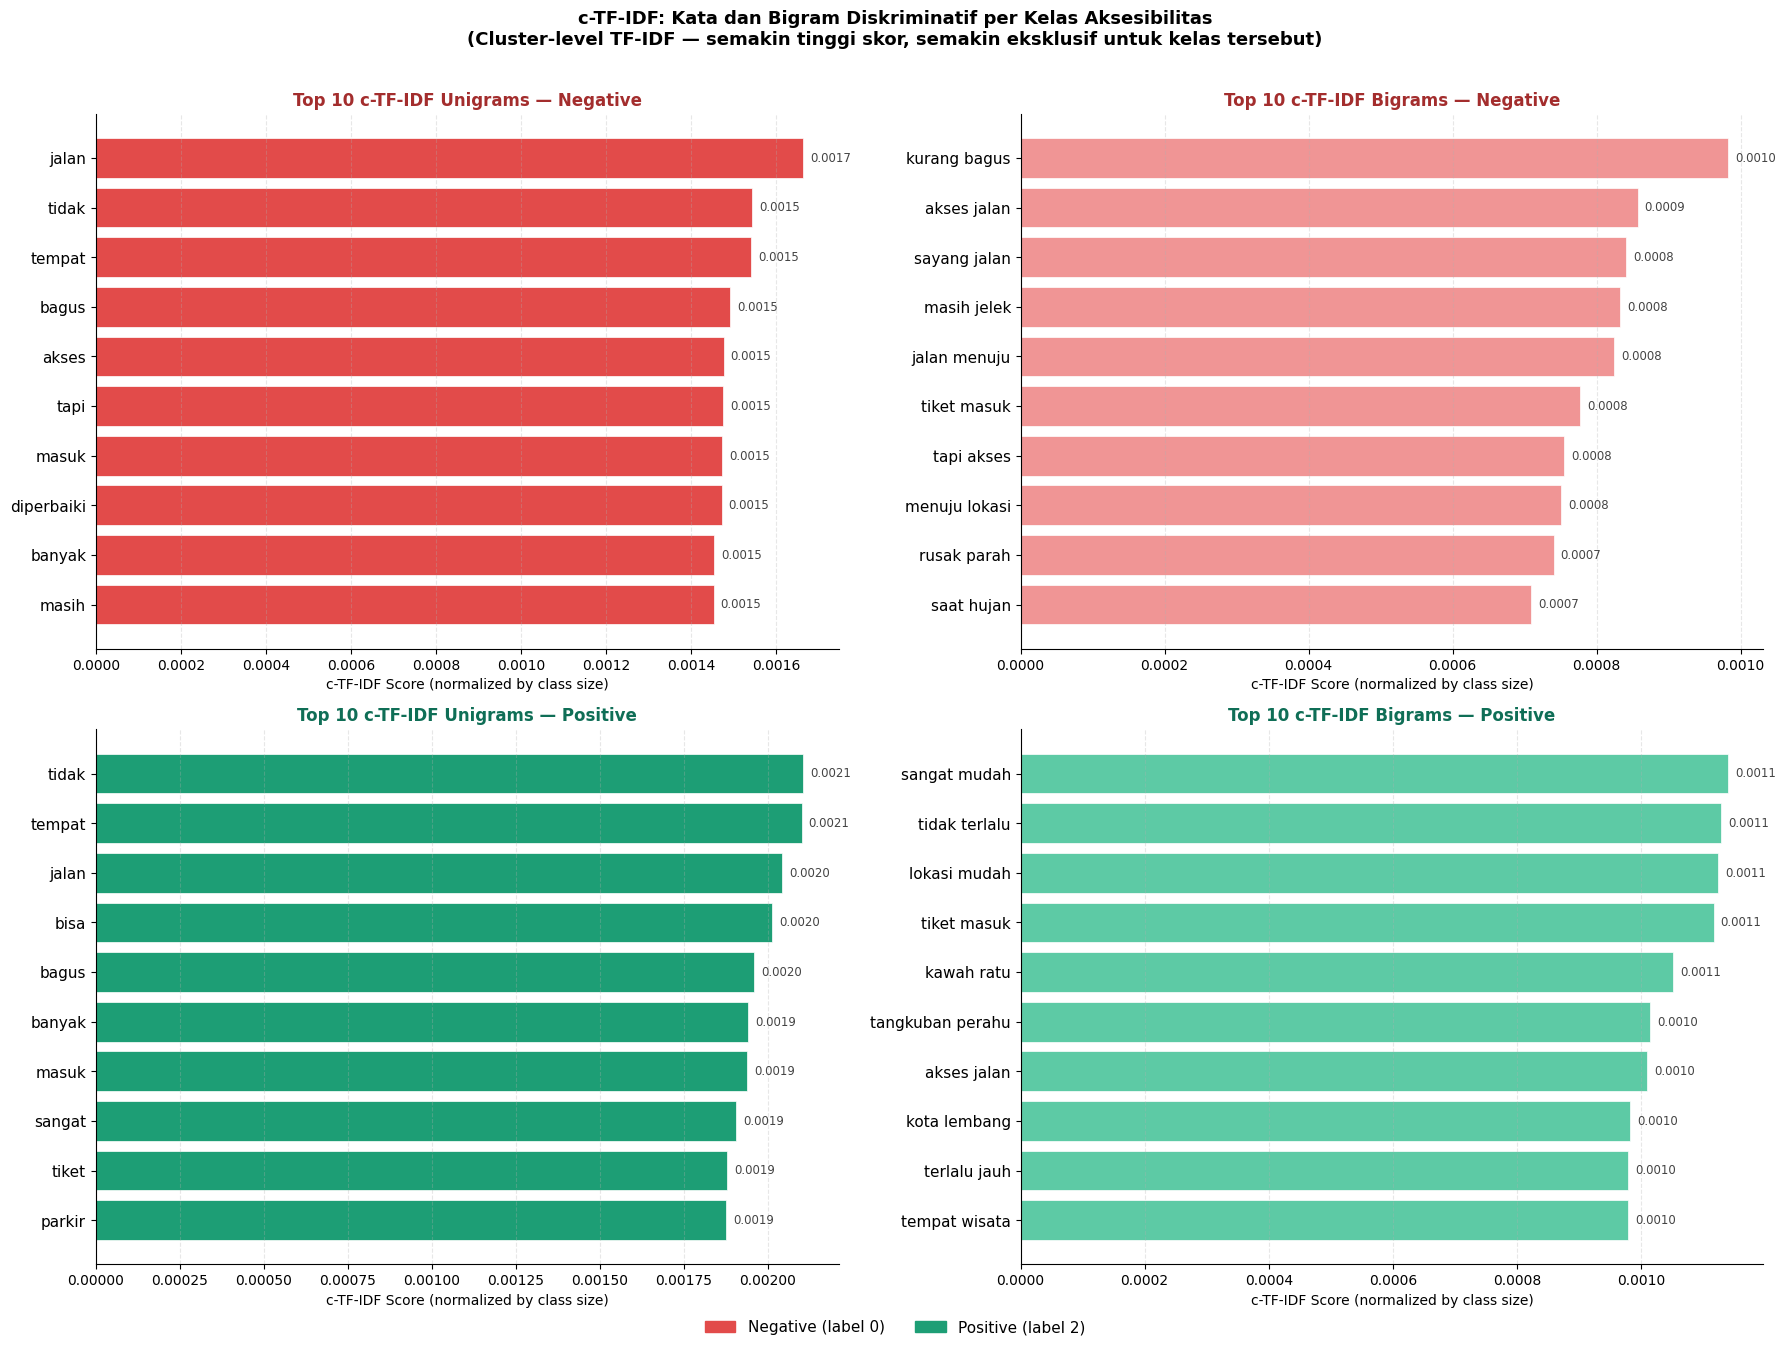

In [17]:
#  Filter hanya label positif (2) dan negatif (0)
df_q2 = df[df['accessibility'].isin([0, 2])].copy()
df_q2['label_name'] = df_q2['accessibility'].map({0: 'Negative', 2: 'Positive'})
df_q2['text_clean'] = df_q2['text_clean'].fillna('')

#  Custom stop words
stopwords_removable = {'yang', 'dan', 'di', 'untuk', 'nya', 'juga', 'ke', 'dari', 'ada', 'dengan', 'ini', 'itu'}
kata_kunci_sentimen = {'tidak', 'kurang', 'belum', 'terlalu', 'sangat', 'bagus', 'mudah', 'jalan', 'akses'}
custom_stop_words = list(stopwords_removable - kata_kunci_sentimen)

# c-TF-IDF
def compute_ctfidf(df, text_col, label_col, ngram_range=(1,1), top_n=10, stop_words=None):
    """
    c-TF-IDF: Cluster-level TF-IDF (BERTopic approach)

    TF (term frequency) dihitung dalam KELAS (mega-dokumen per kelas),
    IDF dihitung berdasarkan frekuensi antar kelas sehingga kata yang eksklusif
    pada satu kelas mendapat bobot tinggi.
    """
    labels = df[label_col].unique()

    # Gabungkan semua teks per kelas
    class_docs = {}
    class_sizes = {}
    for lbl in labels:
        mask = df[label_col] == lbl
        class_docs[lbl] = ' '.join(df.loc[mask, text_col].tolist())
        class_sizes[lbl] = mask.sum()

    # Fit TF-IDF pada mega-dokumen
    corpus = [class_docs[lbl] for lbl in labels]
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        min_df=1,
        max_df=1.0,
        stop_words=stop_words,
        sublinear_tf=True  # mengurangi dominasi kata ultra-frekuen
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    feature_names = np.array(vectorizer.get_feature_names_out())

    # Hitung c-TF-IDF: normalize by class size agar adil
    results = {}
    for i, lbl in enumerate(labels):
        scores = np.asarray(tfidf_matrix[i].todense()).ravel()

        # Normalize by sqrt(class_size) untuk menghindari bias kelas besar
        scores = scores / np.sqrt(class_sizes[lbl])
        top_idx = scores.argsort()[::-1][:top_n]
        results[lbl] = {
            'terms': feature_names[top_idx],
            'scores': scores[top_idx]
        }
    return results

# Hitung c-TF-IDF untuk unigram dan bigram
ctfidf_uni = compute_ctfidf(df_q2, 'text_clean', 'accessibility',
                             ngram_range=(1,1), top_n=10, stop_words=custom_stop_words)
ctfidf_bi  = compute_ctfidf(df_q2, 'text_clean', 'accessibility',
                             ngram_range=(2,2), top_n=10, stop_words=custom_stop_words)

#  Plotting
COLORS = {
    'neg_uni': '#E24B4A',
    'neg_bi' : '#F09595',  # negatif bigram
    'pos_uni': '#1D9E75',
    'pos_bi' : '#5DCAA5',  # positif bigram
}

label_map   = {0: 'Negative', 2: 'Positive'}
label_order = [0, 2]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('c-TF-IDF: Kata dan Bigram Diskriminatif per Kelas Aksesibilitas\n'
             '(Cluster-level TF-IDF — semakin tinggi skor, semakin eksklusif untuk kelas tersebut)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, label_id in enumerate(label_order):
    label_name = label_map[label_id]

    # Unigram
    uni_terms  = ctfidf_uni[label_id]['terms'][::-1]
    uni_scores = ctfidf_uni[label_id]['scores'][::-1]
    color_uni  = COLORS['neg_uni'] if label_id == 0 else COLORS['pos_uni']

    bars = axes[row_idx, 0].barh(uni_terms, uni_scores, color=color_uni, edgecolor='white', linewidth=0.5)
    axes[row_idx, 0].set_title(f'Top 10 c-TF-IDF Unigrams — {label_name}',
                                fontsize=12, fontweight='bold',
                                color='#A32D2D' if label_id == 0 else '#0F6E56')
    axes[row_idx, 0].set_xlabel('c-TF-IDF Score (normalized by class size)', fontsize=10)
    axes[row_idx, 0].tick_params(axis='y', labelsize=11)
    axes[row_idx, 0].spines[['top', 'right']].set_visible(False)
    axes[row_idx, 0].grid(axis='x', alpha=0.3, linestyle='--')

    # Annotate nilai skor di ujung bar
    for bar, score in zip(bars, uni_scores):
        axes[row_idx, 0].text(bar.get_width() + max(uni_scores)*0.01, bar.get_y() + bar.get_height()/2,
                               f'{score:.4f}', va='center', fontsize=8.5, color='#444')

    # Bigram
    bi_terms  = ctfidf_bi[label_id]['terms'][::-1]
    bi_scores = ctfidf_bi[label_id]['scores'][::-1]
    color_bi  = COLORS['neg_bi'] if label_id == 0 else COLORS['pos_bi']

    bars2 = axes[row_idx, 1].barh(bi_terms, bi_scores, color=color_bi, edgecolor='white', linewidth=0.5)
    axes[row_idx, 1].set_title(f'Top 10 c-TF-IDF Bigrams — {label_name}',
                                fontsize=12, fontweight='bold',
                                color='#A32D2D' if label_id == 0 else '#0F6E56')
    axes[row_idx, 1].set_xlabel('c-TF-IDF Score (normalized by class size)', fontsize=10)
    axes[row_idx, 1].tick_params(axis='y', labelsize=11)
    axes[row_idx, 1].spines[['top', 'right']].set_visible(False)
    axes[row_idx, 1].grid(axis='x', alpha=0.3, linestyle='--')
    for bar2, score2 in zip(bars2, bi_scores):
        axes[row_idx, 1].text(bar2.get_width() + max(bi_scores)*0.01, bar2.get_y() + bar2.get_height()/2,
                               f'{score2:.4f}', va='center', fontsize=8.5, color='#444')

# Legend kelas
neg_patch = mpatches.Patch(color=COLORS['neg_uni'], label='Negative (label 0)')
pos_patch = mpatches.Patch(color=COLORS['pos_uni'], label='Positive (label 2)')
fig.legend(handles=[neg_patch, pos_patch], loc='lower center',
           ncol=2, fontsize=11, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

**Insight:**

**Unigram:**
- Unigram kelas **Negative** didominasi oleh kata `jalan`, `tidak`, `akses`, `diperbaiki`, dan `masih` dimana pola ini mengindikasikan ulasan negatif banyak membicarakan kondisi jalan yang bermasalah dan harapan perbaikan yang belum terpenuhi.
- Unigram kelas **Positive** didominasi oleh kata `sangat`, `bisa`, `parkir`, dan `tiket` — berbeda dengan kelas negatif yang terfokus pada kondisi jalan, ulasan positif lebih merayakan aspek kemudahan akses secara menyeluruh seperti parkir yang tersedia dan tiket yang mudah didapat.

**Bigram (lebih diskriminatif):**
- Frasa dengan nilai c-TF_IDF tertinggi di Bigram kelas **Negative** mencakup: `kurang bagus`, `sayang jalan`, `masih jelek`, `rusak parah`, dan `saat hujan` secara eksplisit menggambarkan keluhan aksesibilitas seperti jalan yang rusak, terutama saat musim hujan.
-  Frasa dengan nilai c-TF_IDF tertinggi di Bigram kelas **Positive** mencakup: `sangat mudah`, `lokasi mudah`, `akses jalan` (dalam konteks positif), dan `tidak terlalu jauh` menggambarkan persepsi akses yang mudah dan jarak yang terjangkau.
- Munculnya nama lokasi spesifik seperti `kawah ratu`, `tangkuban perahu`, dan `kota lembang` pada Bigram kelas **Positive** mengindikasikan bahwa lokasi-lokasi ini mendapat penilaian aksesibilitas positif dari pengunjung.
- Frasa `tiket masuk` muncul di **kedua kelas** — artinya aspek tiket dibicarakan baik oleh reviewer positif maupun negatif, kemungkinan karena harganya dianggap sebanding oleh yang puas, namun dianggap tidak worth it oleh yang kecewa dengan aksesibilitasnya.

**Kesimpulan:**  c-TF-IDF mengonfirmasi bahwa bigram — sangat potensial sebagai fitur untuk model klasifikasi aksesibilitas. Kondisi jalan (khususnya saat hujan) adalah isu utama kelas negatif, sementara kemudahan akses dan kedekatan lokasi menjadi penanda kuat kelas positif.

### Pertanyaan 3: Bagaimana proporsi bulanan label aksesibilitas negatif, netral, dan positif berubah sepanjang 2019 –  2023, dan apakah terdapat tren atau pola musiman?



In [18]:
# 1. Persiapan: Pastikan kolom datetime dalam format yang benar
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Membuat kolom bantuan untuk grouping (Tahun-Bulan)
df['month'] = df['datetime'].dt.to_period('M')

# 3. Membuat fungsi untuk menghitung frekuensi nilai (0, 1, 2)
def count_vals(x):
    return x.value_counts().reindex([0, 1, 2], fill_value=0)

# 4. Agregasi data bulanan: rata-rata rating dan total review
df_monthly = df.groupby('month').agg(
    rating=('rating', 'mean'),
    review_count=('id', 'count')
).reset_index()

# Tambahkan tren sentimen (Aksesibilitas, Fasilitas, Aktivitas): count + proporsi (%)
for col in ['accessibility', 'facility', 'activity']:
    trend = df.groupby('month')[col].apply(count_vals).unstack(fill_value=0)
    trend.columns = [f'{col}_{i}' for i in range(3)]

    # Hitung proporsi sentimen per bulan berdasarkan total review bulanan
    for i in range(3):
        trend[f'{col}_{i}_pct'] = (trend[f'{col}_{i}'] / trend.sum(axis=1)) * 100

    df_monthly = df_monthly.merge(trend, on='month')

# Ubah format month kembali ke datetime agar lancar saat plotting
df_monthly['month'] = df_monthly['month'].dt.to_timestamp()

# Menampilkan hasil df_monthly
df_monthly.head()

,month,rating,review_count,accessibility_0,accessibility_1,accessibility_2,accessibility_0_pct,accessibility_1_pct,accessibility_2_pct,facility_0,...,facility_2,facility_0_pct,facility_1_pct,facility_2_pct,activity_0,activity_1,activity_2,activity_0_pct,activity_1_pct,activity_2_pct
0,2019-02-01,4.376475,2457,204,2138,115,8.302808,86.723627,4.506223,285,...,377,11.599512,72.713293,14.834852,89,844,1524,3.622304,34.300266,61.084060
1,2020-02-01,4.414056,2234,168,1965,101,7.520143,87.663723,4.336283,237,...,370,10.608774,72.484792,15.968281,100,742,1392,4.476276,33.147548,61.277751
2,2021-02-01,4.543624,1490,152,1253,85,10.201342,83.522122,5.367099,113,...,282,7.583893,73.117774,17.953760,36,581,873,2.416107,38.930161,57.008661
3,2022-02-01,4.594086,1860,131,1639,90,7.043011,87.785873,4.603984,178,...,399,9.569892,68.625410,20.586161,58,714,1088,3.118280,38.322849,57.219757
4,2022-03-01,4.655172,203,14,175,14,6.896552,83.374404,4.773742,23,...,53,11.330049,59.254407,19.372446,7,63,133,3.448276,30.516118,56.126576


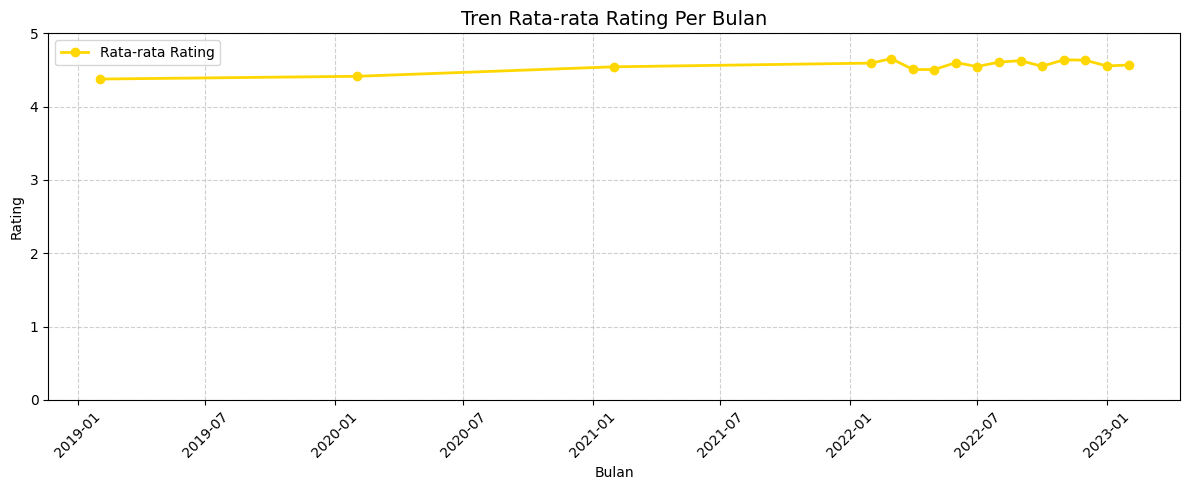

In [19]:
# Plot 1: Tren Rata-rata Rating Per Bulan
plt.figure(figsize=(12, 5))
plt.plot(
    df_monthly['month'],
    df_monthly['rating'],
    marker='o',
    color='gold',
    linewidth=2,
    label='Rata-rata Rating'
)

# Menentukan batas sumbu Y.
# bottom=0 memastikan mulai dari nol.
# top=5.5 ditambahkan agar ada ruang di atas jika rating maksimal adalah 5.
plt.ylim(bottom=0, top=5)

plt.title('Tren Rata-rata Rating Per Bulan', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

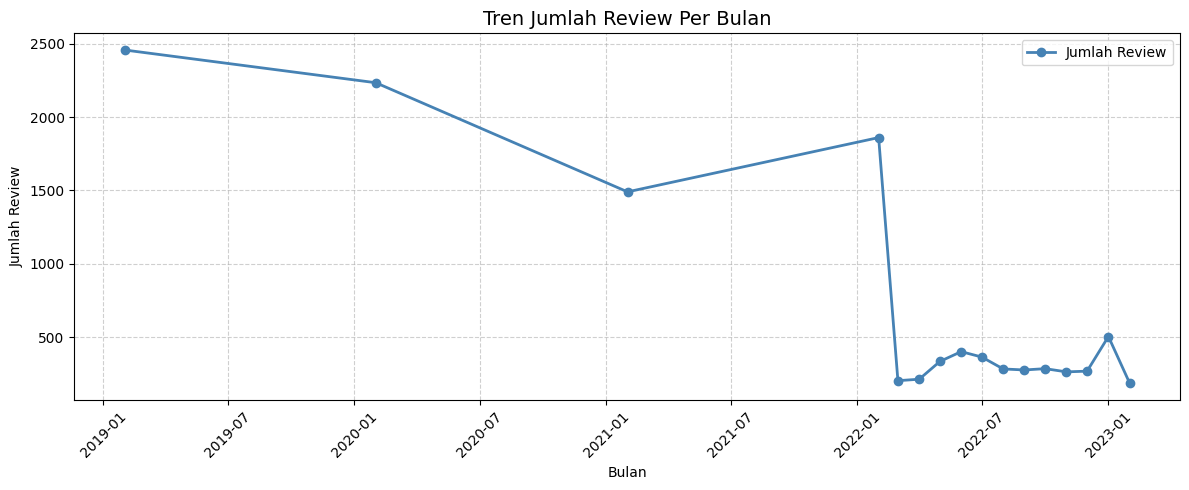

In [20]:
# Plot 2: Tren Jumlah Review Per Bulan
plt.figure(figsize=(12, 5))
plt.plot(
    df_monthly['month'],
    df_monthly['review_count'],
    marker='o',
    color='steelblue',
    linewidth=2,
    label='Jumlah Review'
)

plt.title('Tren Jumlah Review Per Bulan', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

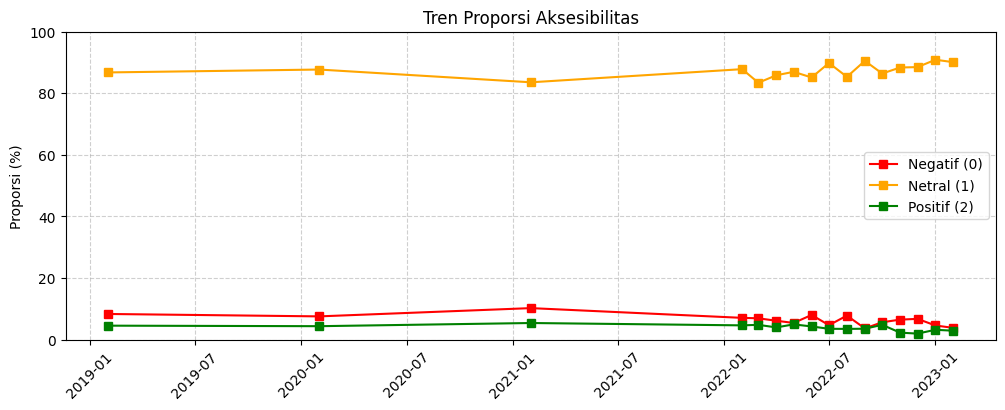

In [21]:
# Plot 3: Tren Proporsi Aksesibilitas
plt.figure(figsize=(12, 4))
plt.plot(df_monthly['month'], df_monthly['accessibility_0_pct'], label='Negatif (0)', marker='s', color='red')
plt.plot(df_monthly['month'], df_monthly['accessibility_1_pct'], label='Netral (1)', marker='s', color='orange')
plt.plot(df_monthly['month'], df_monthly['accessibility_2_pct'], label='Positif (2)', marker='s', color='green')
plt.title('Tren Proporsi Aksesibilitas', fontsize=12)
plt.ylabel('Proporsi (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Rating bulanan sangat stabil sepanjang 2019–2023, bergerak dalam rentang sempit 4.35–4.65, tanpa tren naik atau turun yang signifikan.
- Jumlah review menunjukkan tren penurunan bertahap sejak awal 2019 (~2500) hingga awal 2022 (~1850), diikuti oleh drop drastis di pertengahan 2022 menjadi sekitar 200 review per bulan. Kemungkinan besar merupakan dampak penutupan atau pembatasan wisata pasca-pandemi.
- Fluktuasi rating di 2022–2023 yang sedikit lebih terlihat kemungkinan disebabkan oleh volume review yang jauh lebih kecil, sehingga setiap ulasan punya bobot proporsional yang lebih besar terhadap rata-rata.
- Tidak terlihat tren atau pola musiman yang konsisten secara visual pada proporsi label aksesibilitas sepanjang periode 2019–2023.

## Referensi

https://www.kaggle.com/code/harshsingh2209/complete-guide-to-eda-on-text-data#Most-Frequently-occuring-N_grams
